In [1]:
import os, sys, numpy as np

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.10.12
CWD: /local0/rossin/git/CRN-GenerativeAI/apps


In [ ]:
from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

In [ ]:
from RL4CRN.utils.crn_builders import build_simple_IOCRN

# choose preset
cfg = Configurator.preset("paper")

# select simulator and set tolerances
cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10

# build template IO/CRN
species_labels = ['X_1', 'X_2', 'X_3']
crn, species_labels = build_simple_IOCRN(
    species=species_labels,
    production_input_map={"X_1": "u_1"},
    dilution_map={},
    output_species="X_3",
    solver=cfg.solver,
)

from RL4CRN.utils.library_builders import build_MAK_library

# library components
library_components = build_MAK_library(crn, species_labels, order=2)

In [ ]:
periods = [10, 15, 20]
task = make_task(
    template_crn=crn,
    library_components=library_components,
    kind="oscillator_freq",
    species_labels=species_labels, # TODO infer from template_crn
    n_inputs=1, # TODO infer from template_crn
    u_values=[1/p for p in periods],
    ic=("constant", 0.01),
    osc_w=[0/10, 6/10, 1/10, 3/10],                              # [mean, frequency, damping, periodicity index]
    t_f=100, n_t=1000
)
print_task_summary(task)

Task: oscillator_freq
time_horizon: (1000,) [0..100.0]
num scenarios: 3
first 3 u: [array([0.1], dtype=float32), array([0.06666667], dtype=float32), array([0.05], dtype=float32)]



In [16]:
# ---- Train config ----
cfg.train.max_added_reactions = 5
cfg.train.epochs = 5
cfg.train.render_every = 5
cfg.train.seed = 0

In [ ]:
cfg.describe()

{'task': {'template_crn': <RL4CRN.iocrns.iocrn.IOCRN object at 0x7f8c1a1fe290>,
          'library_components': (<RL4CRN.iocrns.reaction_library.ReactionLibrary object at 0x7f8c1a1fc490>,
                                 91,
                                 91,
                                 {'continuous': array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
 

: 

In [19]:
session, trainer = make_session_and_trainer(cfg, task)

In [ ]:
checkpoint_path = "oscillators.pkl"
trainer.run(epochs=cfg.train.epochs, checkpoint_path=checkpoint_path)


[cvHandleFailure, Error: -15] At t = 59.5217908580647, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.7439351609237, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 42.1426688742265, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 76.1187800216896, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.13950267356795, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 42.9893056688721, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 20.2830142234818, unable to satisfy inequality constraints.

[epoch 0] best loss=0.4039 | median loss=1
Saved checkpoint: logic_task_chkpt.pkl

[CVode, Error: -1] At t = 20.4915989587822, mxstep steps taken before reaching tout.


[CVode, Error: -1] At t = 22.6130042702919, mxstep steps taken before reaching tout.


[cvHandleFailure, Error: -15] At t = 17.55777756984

Best loss: 0.4038845677503494
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2 + X_2;  [MAK(0.34711575508117676)]
X_3 ----> X_1 + X_3;  [MAK(0.09864094108343124)]
X_1 + X_3 ----> X_1;  [MAK(0.2804798483848572)]
X_2 + X_3 ----> X_1;  [MAK(0.4052799940109253)]
X_2 + X_3 ----> X_3 + X_3;  [MAK(0.6915748119354248)]
Hall of Fame size: 50
Best loss: 0.4038845677503494


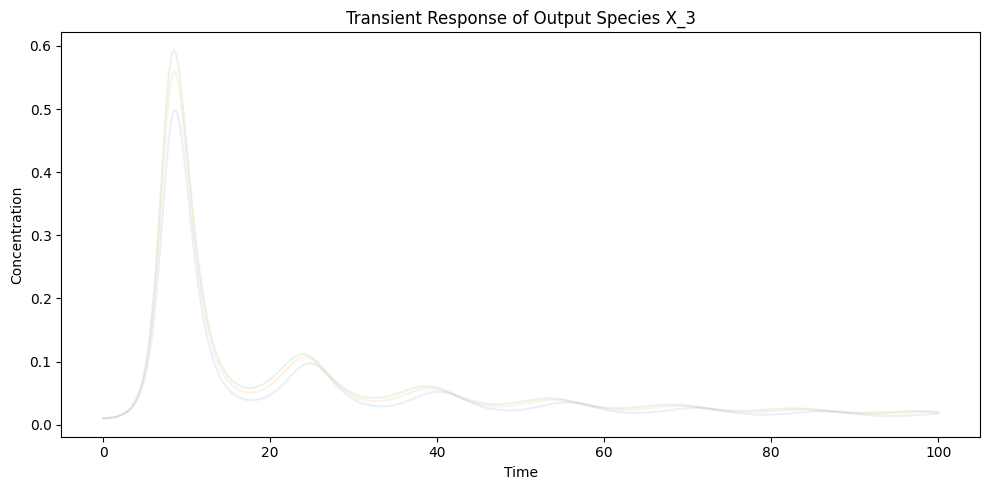

In [22]:
trainer.inspect_best(plot=True)

best = trainer.best_crn()
print("Hall of Fame size:", len(session.mult_env.hall_of_fame))
if best is not None:
    print("Best loss:", best.last_task_info.get("reward", None))
